### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [1]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")



### Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

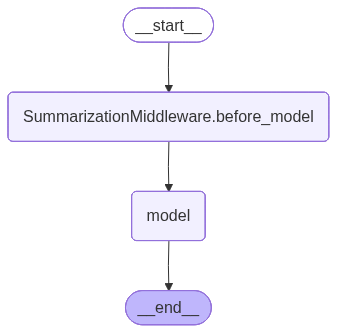

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

agent

In [7]:
# run with tread id
config = {"configurable": {"thread_id": "test1"}}

In [8]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='e9d9b340-8412-42ae-bcf4-9a7115bbf980'), AIMessage(content="<think>\nOkay, so I need to figure out what 2 + 2 is. Let me start by recalling basic arithmetic. Addition is one of the first math operations I learned. When you add two numbers, you're combining their quantities. So, 2 plus 2 would be taking two objects and adding another two objects to them. Let me visualize this. If I have two apples and then get two more apples, how many apples do I have in total? That should be four apples. \n\nWait, but maybe I should break it down step by step. Starting with the number 2, if I add 2 to it, I can count forward two numbers from 2. So, 2, then 3, 4. Yeah, that gives me 4. Another way to think about it is using my fingers. If I hold up two fingers on one hand and two on the other, putting them together gives me four fingers. \n\nIs there another method? Maybe using number lines. If I

### Human in the Loop Middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

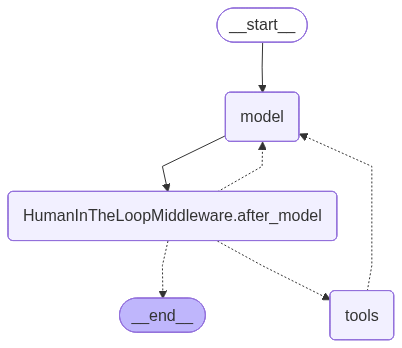

In [10]:
agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

agent

In [11]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [12]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='c4e419d6-ec4d-447d-88ff-673e7927c92a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the tools provided. There's a send_email_tool that requires recipient, subject, and body. The parameters are all there: recipient is the email address provided, subject is 'Hello', and body is 'How are you?'. I need to make sure all required fields are included. Yes, they are. So I should call the send_email_tool with these arguments. No other tools are needed here since the user isn't asking to read an email. Just need to structure the JSON correctly within the tool_call tags.\n", 'tool_calls': [{'id': 'ksfzb8h0h', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}

In [13]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: ✅ Email with subject "Hello" has been successfully sent to john@test.com. Let me know if you need to send or read any other emails!


In [14]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='c4e419d6-ec4d-447d-88ff-673e7927c92a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the tools provided. There's a send_email_tool that requires recipient, subject, and body. The parameters are all there: recipient is the email address provided, subject is 'Hello', and body is 'How are you?'. I need to make sure all required fields are included. Yes, they are. So I should call the send_email_tool with these arguments. No other tools are needed here since the user isn't asking to read an email. Just need to structure the JSON correctly within the tool_call tags.\n", 'tool_calls': [{'id': 'ksfzb8h0h', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}

### Reject

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [22]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [23]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email sending request was rejected. To assist further, could you provide more details about the rejection (e.g., error message) or confirm if you'd like to try adjusting the email parameters?


In [24]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='0b664da9-e2b7-447d-a9aa-2fd2e0d253d4'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. I need to structure the function call with those parameters. Let me make sure I have the arguments correctly: recipient is john@test.com, subject is Hello, body is How are you?. Yep, that's all there. No need for the read_email_tool here since the task is to send, not read. So the correct tool to call is send_email_tool with those arguments.\n", 'tool_calls': [{'id': 'ggw7ksk9t', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subjec

### Editing

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [27]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [28]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='6d563a00-8003-4baa-8737-6ab1066cf5fd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. The parameters are all there: recipient is the email address provided, subject is 'Test', and body is 'Hello'. I need to make sure all required fields are included. Yep, all three are required and present. I'll call the send_email_tool with these arguments.\n", 'tool_calls': [{'id': 'mxrx15bay', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 249, 'total_tokens':

In [29]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been successfully sent to **correct@email.com** with the subject **"Corrected Subject"** and the body **"This was edited by human before sending"**. Let me know if you'd like to review or adjust any details!


In [30]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='6d563a00-8003-4baa-8737-6ab1066cf5fd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. The parameters are all there: recipient is the email address provided, subject is 'Test', and body is 'Hello'. I need to make sure all required fields are included. Yep, all three are required and present. I'll call the send_email_tool with these arguments.\n", 'tool_calls': [{'id': 'mxrx15bay', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 249, 'total_tokens':